In [21]:
import pystac_client
import planetary_computer as pc
import odc.stac
from shapely.geometry import box, mapping, shape, Point
from IPython.display import Image
import rioxarray
from urllib.parse import urlparse, parse_qs

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

In [3]:
catalog.get_collections()

<generator object Client.get_collections at 0x000001C23A78F9A0>

In [4]:
collections=list(catalog.get_collections())

In [5]:
reference_point=Point(-63.90, -8.76)
recent_window = "2023-06-01/2023-06-30"

wide_search_area = reference_point.buffer(0.5)

candidates_nearby = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=mapping(wide_search_area),
    datetime=recent_window,
    max_items=100,
).items()
candidates_nearby = list(candidates_nearby)
print(len(candidates_nearby), "scenes found nearby")



88 scenes found nearby


In [7]:
candidates_nearby[0].id

'S2B_MSIL2A_20230629T142719_R053_T20LMR_20241002T184523'

In [8]:
candidates_nearby[0].datetime

datetime.datetime(2023, 6, 29, 14, 27, 19, 24000, tzinfo=tzutc())

In [9]:
candidates_nearby[0].geometry

{'type': 'Polygon',
 'coordinates': [[[-63.9088968, -8.4783641],
   [-63.8952258, -8.4182123],
   [-63.8615037, -8.2697454],
   [-63.832368, -8.141095],
   [-62.9114022, -8.1420245],
   [-62.9111701, -9.135193],
   [-63.9104673, -9.1340626],
   [-63.9088968, -8.4783641]]]}

In [11]:
candidates_nearby[0].bbox

[-63.9104673, -9.135193, -62.9111701, -8.141095]

In [12]:
candidates_nearby[0].properties

{'datetime': '2023-06-29T14:27:19.024000Z',
 'platform': 'Sentinel-2B',
 'instruments': ['msi'],
 's2:mgrs_tile': '20LMR',
 'constellation': 'Sentinel 2',
 's2:granule_id': 'S2B_OPER_MSI_L2A_TL_S2RP_20241002T184523_A032969_T20LMR_N05.10',
 'eo:cloud_cover': 0.002857,
 's2:datatake_id': 'GS2B_20230629T142719_032969_N05.10',
 's2:product_uri': 'S2B_MSIL2A_20230629T142719_N0510_R053_T20LMR_20241002T184523.SAFE',
 's2:datastrip_id': 'S2B_OPER_MSI_L2A_DS_S2RP_20241002T184523_S20230629T143340_N05.10',
 's2:product_type': 'S2MSI2A',
 'sat:orbit_state': 'descending',
 's2:datatake_type': 'INS-NOBS',
 's2:generation_time': '2024-10-02T18:45:23.000000Z',
 'sat:relative_orbit': 53,
 's2:water_percentage': 5.441534,
 's2:mean_solar_zenith': 40.4396187104278,
 's2:mean_solar_azimuth': 37.5240275360093,
 's2:processing_baseline': '05.10',
 's2:snow_ice_percentage': 0.0,
 's2:vegetation_percentage': 90.360087,
 's2:thin_cirrus_percentage': 0.001124,
 's2:cloud_shadow_percentage': 0.000858,
 's2:nodat

In [14]:
candidates_nearby[0].assets.keys()

dict_keys(['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview'])

In [16]:
Image(url=candidates_nearby[0].assets["rendered_preview"].href)

(3, 687, 687)


Matplotlib is building the font cache; this may take a moment.


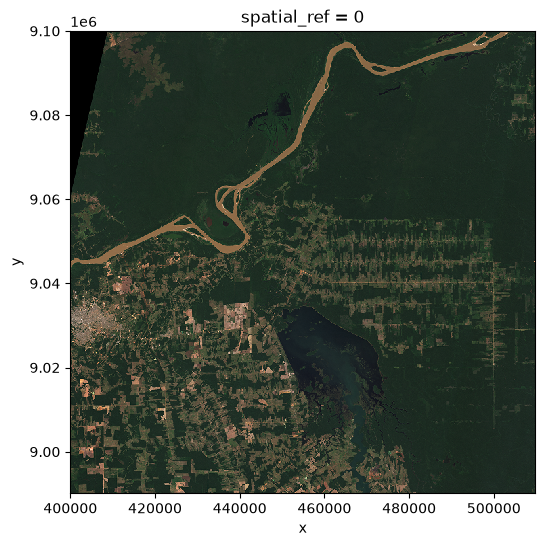

In [19]:
visual = rioxarray.open_rasterio(candidates_nearby[0].assets["visual"].href, overview_level=3)
print(visual.shape)
visual.plot.imshow(figsize=(6, 6))

In [20]:
candidates_nearby[0].assets["B04"]

<Asset href=https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/20/L/MR/2023/06/29/S2B_MSIL2A_20230629T142719_N0510_R053_T20LMR_20241002T184523.SAFE/GRANULE/L2A_T20LMR_A032969_20230629T143340/IMG_DATA/R10m/T20LMR_20230629T142719_B04_10m.tif?st=2026-09-22T13%3A07%3A35Z&se=2026-09-23T13%3A52%3A35Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-09-23T12%3A55%3A36Z&ske=2026-09-30T12%3A55%3A36Z&sks=b&skv=2025-07-05&sig=Ui7DOIH1bbCeeK858zWACNwQKBfPHSCYE3j5CmZPMmo%3D>

In [23]:
url = urlparse(candidates_nearby[0].assets["B04"].href)
print(url.path)                     
for nome, valore in parse_qs(url.query).items():
    print(nome, "=", valore[0])

/sentinel2-l2/20/L/MR/2023/06/29/S2B_MSIL2A_20230629T142719_N0510_R053_T20LMR_20241002T184523.SAFE/GRANULE/L2A_T20LMR_A032969_20230629T143340/IMG_DATA/R10m/T20LMR_20230629T142719_B04_10m.tif
st = 2026-09-22T13:07:35Z
se = 2026-09-23T13:52:35Z
sp = rl
sv = 2025-07-05
sr = c
skoid = 9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a
sktid = 72f988bf-86f1-41af-91ab-2d7cd011db47
skt = 2026-09-23T12:55:36Z
ske = 2026-09-30T12:55:36Z
sks = b
skv = 2025-07-05
sig = Ui7DOIH1bbCeeK858zWACNwQKBfPHSCYE3j5CmZPMmo=
